In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

**<font size="10" color="red">ch9.Transformer 인코더로 영화평 구분하기 </font>**

- imdb의 5만개 영화감상평

# 1. 패키지 import

In [2]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from time import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense #,Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, recall_score, precision_score,f1_score
import pandas as pd

# 2. 하이퍼 파라미터 설정(이 파라미터를 바꾸면 score나 설정에 차이)

In [3]:
MY_WORDS = 10000 # imdb 데이터안의 단어수
MY_LENGTH = 80 # 영화평 단어수 80개까지만 독립변수(200추천)
MY_EMBED = 32 # 임배딩 layer의 출력자원(256추천)
MY_HIDDEN = 64

MY_EPOCH = 10 # 반복 학습 수(fit 20추천)
MY_BATCH = 200 # 매번 가져오는 데이터수
# 불용어 인덱스 설정(빈도수 상위 40개는 제외 : the, a, is등)
SKIP_TOP = 40

# 3. 데이터 불러오기

In [6]:
(X_train,y_train),(X_test,y_test) = imdb.load_data(num_words=MY_WORDS)

In [7]:
# 부/긍정 갯수 확인
pd.Series(y_train).value_counts()#.sort_index()

1    12500
0    12500
dtype: int64

# 4. 문자단어->정수

In [4]:
word_to_id = imdb.get_word_index() # dict (단어:id값) : 빈도수가 높은 단어를 id앞에
print(word_to_id['movie'])
print(word_to_id['film'])
print(word_to_id['the'])
# 정수 : 단어 dict
id_to_word = {}
for word, id in word_to_id.items():
    id_to_word[id] = word
print(id_to_word[17])
print(id_to_word[19])
print(id_to_word[1])

17
19
1
movie
film
the


# 5. 숫자 영화평 -> 자연어 영화평 함수

In [11]:
def decoding(review_num):
    "숫자 영화평을 자연어 영화평으로 바꿔줘"
    decoded = [id_to_word.get(d-3,'??') for d in review_num]
    return ' '.join(decoded)
decoding(X_train[0]),y_train[0]

("?? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ?? is an amazing actor and now the same being director ?? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ?? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ?? to the two little boy's that played the ?? of norman and paul they were just brilliant children are often left out of the ?? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don'

In [17]:
X_train[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

# 6. 영화평 데이터 100개 길이 출력함수

In [7]:
def show_length(X_train=X_train):
    print('0,100,200번째 등 100개 영화평 단어 길이')
    print([len(x_data) for x_data in X_train[:1000:100]])
#     for i in range(5):
#         print(f'{i}번째 길이 : {len(X_train[i])}')

In [8]:
#print('pad sequence 작업 전')
show_length(X_train)
show_length(X_test)

0,100,200번째 등 100개 영화평 단어 길이
[218, 158, 160, 229, 486, 60, 467, 133, 166, 223]
0,100,200번째 등 100개 영화평 단어 길이
[68, 135, 100, 416, 86, 126, 112, 154, 136, 161]


# 7. 모든 영화평의 길이를 동일하게(MY_LENGTH만큼)

In [19]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape


((25000,), (25000,), (25000,), (25000,))

In [9]:
X_train = pad_sequences(X_train,
                       maxlen=MY_LENGTH,
                       truncating='post',
                       # truncating='pre'
                       padding='pre', # 80단어 미만일 경우 앞에 zero를 붙임
                       # padding = 'post' 
                       )
X_test = pad_sequences(X_test,
                       maxlen=MY_LENGTH,
                       truncating='post',
                       # truncating='pre'
                       padding='pre', # 80단어 미만일 경우 앞에 zero를 붙임
                       # padding = 'post' 
                       )
show_length(X_train)
show_length(X_test)

0,100,200번째 등 100개 영화평 단어 길이
[80, 80, 80, 80, 80, 80, 80, 80, 80, 80]
0,100,200번째 등 100개 영화평 단어 길이
[80, 80, 80, 80, 80, 80, 80, 80, 80, 80]


In [34]:
X_test[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    1,  591,  202,   14,   31,    6,  717,   10,   10,    2,
          2,    5,    4,  360,    7,    4,  177, 5760,  394,  354,    4,
        123,    9, 1035, 1035, 1035,   10,   10,   13,   92,  124,   89,
        488, 7944,  100,   28, 1668,   14,   31,   23,   27, 7479,   29,
        220,  468,    8,  124,   14,  286,  170,    8,  157,   46,    5,
         27,  239,   16,  179,    2,   38,   32,   25, 7944,  451,  202,
         14,    6,  717])

# 8. 최종 데이터 shape확인

In [10]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000, 80), (25000,), (25000, 80), (25000,))

# 9.모델  생성 구현(tranceformer 인코더부분-이진 분류)
- 이진분류 == 로지스틱회귀분(0/1)

In [47]:
from tensorflow import range
from tensorflow.keras.layers import(Dropout, Input, MultiHeadAttention, add,GlobalAvgPool1D,
                                    BatchNormalization, LayerNormalization,
                                    GlobalAvgPool1D)
from tensorflow.keras.models import Model,Sequential

INPUTS = Input(shape=(MY_LENGTH,))
INPUT_EMBEDDING = Embedding(input_dim = MY_WORDS,
                           output_dim = MY_EMBED,
                           )(INPUTS)
# positional encoding
POSITIONS = range(start=0,limit=MY_LENGTH)
POS_ENCODING = Embedding(input_dim=MY_LENGTH,
                        output_dim=MY_EMBED)(POSITIONS)
POS_ENC_OUTPUT = POS_ENCODING + INPUT_EMBEDDING

# Multi-Head-Attention(self attention)
ATTENTION_OUTPUT = MultiHeadAttention(num_heads=3,
                                     key_dim=MY_EMBED//3,
                                     dropout=0.2)(POS_ENC_OUTPUT,POS_ENC_OUTPUT)
X = add([POS_ENC_OUTPUT,ATTENTION_OUTPUT])
# X = BatchNormalization()
X = LayerNormalization()(X) # trancformers일 때 배치 정규화

# FeedForward Network : 각 토큰마다 적용되는 독립적인 신경망 알고리즘
FFN = Sequential([
    Dense(units=MY_HIDDEN, activation='relu', kernel_regularizer=l2(0.001)), #64
    Dropout(0.2),
    Dense(units=MY_EMBED, activation='relu', kernel_regularizer=l2(0.001))#32
])(X)
X = add([FFN,X])
X = LayerNormalization()(X)

# 1차원으로 압축해서 Dense에 보내주고자
X = GlobalAvgPool1D()(X)
X = Dropout(0.3)(X)

# 최종출력
X = Dense(MY_HIDDEN, activation='relu', name='after-FFN')(X)
X = Dropout(0.1, name='dropt-1')(X)

OUTPUTS = Dense(1,activation='sigmoid',name='output')(X)

models = Model(inputs=INPUTS, outputs=OUTPUTS, name='model')
models.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_16 (InputLayer)          [(None, 80)]         0           []                               
                                                                                                  
 embedding_30 (Embedding)       (None, 80, 32)       320000      ['input_16[0][0]']               
                                                                                                  
 tf.__operators__.add_12 (TFOpL  (None, 80, 32)      0           ['embedding_30[0][0]']           
 ambda)                                                                                           
                                                                                                  
 multi_head_attention_11 (Multi  (None, 80, 32)      3962        ['tf.__operators__.add_12[0][

# 9.모델  생성 구현(tranceformer 인코더부분-다중 분류)
- 다중분류(타겟변수가 10/01)

In [13]:
from tensorflow import range
from tensorflow.keras.layers import(Dropout, Input, MultiHeadAttention, add,GlobalAvgPool1D,
                                    BatchNormalization, LayerNormalization,
                                    GlobalAvgPool1D)
from tensorflow.keras.models import Model,Sequential

INPUTS = Input(shape=(MY_LENGTH,))
INPUT_EMBEDDING = Embedding(input_dim = MY_WORDS,
                           output_dim = MY_EMBED,
                           )(INPUTS)
# positional encoding
POSITIONS = range(start=0,limit=MY_LENGTH)
POS_ENCODING = Embedding(input_dim=MY_LENGTH,
                        output_dim=MY_EMBED)(POSITIONS)
POS_ENC_OUTPUT = POS_ENCODING + INPUT_EMBEDDING

# Multi-Head-Attention(self attention)
ATTENTION_OUTPUT = MultiHeadAttention(num_heads=3,
                                     key_dim=MY_EMBED//3,
                                     dropout=0.2)(POS_ENC_OUTPUT,POS_ENC_OUTPUT)
X = add([POS_ENC_OUTPUT,ATTENTION_OUTPUT])
# X = BatchNormalization()
X = LayerNormalization()(X) # trancformers일 때 배치 정규화

# FeedForward Network : 각 토큰마다 적용되는 독립적인 신경망 알고리즘
FFN = Sequential([
    Dense(units=MY_HIDDEN, activation='relu', kernel_regularizer=l2(0.001)), #64
    Dropout(0.2),
    Dense(units=MY_EMBED, activation='relu', kernel_regularizer=l2(0.001))#32
])(X)
X = add([FFN,X])
X = LayerNormalization()(X)

# 1차원으로 압축해서 Dense에 보내주고자
X = GlobalAvgPool1D()(X)
X = Dropout(0.3)(X)

# 최종출력
X = Dense(MY_HIDDEN, activation='relu', name='after-FFN')(X)
X = Dropout(0.1, name='dropt-1')(X)

OUTPUTS = Dense(2,activation='softmax',name='output')(X) # 분류분석

model = Model(inputs=INPUTS, outputs=OUTPUTS, name='model')
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 80)]         0           []                               
                                                                                                  
 embedding_2 (Embedding)        (None, 80, 32)       320000      ['input_2[0][0]']                
                                                                                                  
 tf.__operators__.add_1 (TFOpLa  (None, 80, 32)      0           ['embedding_2[0][0]']            
 mbda)                                                                                            
                                                                                                  
 multi_head_attention_1 (MultiH  (None, 80, 32)      3962        ['tf.__operators__.add_1[0][0

# 10. 학습설정및 학습하기

In [14]:
model.compile(#loss='binary_crossentropy', 이진분류시 손실함수
             loss='sparse_categorical_crossentropy', #원핫인코딩을 안했을시 다중분류 손실함수  
             optimizer='adam',
             metrics=['acc'])
begin = time() # 70.1.1부터 현재까지의 초수
earlyStopping = EarlyStopping(monitor='val_loss',
                     patience=3,
                     mode='min',
                     restore_best_weights=True, # 멈췄을 경우, val_loss가 가장 낮았던 시점의 가중치로 복원
                     verbose=1) # 언제 멈췄는지 로그 출력
hist = model.fit(X_train, y_train,
                validation_split=0.2,
                epochs=MY_EPOCH,
                batch_size=MY_BATCH,
                verbose=2,
                callbacks=[earlyStopping])
end = time()
print(f'총 학습 시간 : {end-begin:.2f}초')

Epoch 1/10
100/100 - 21s - loss: 0.6230 - acc: 0.7067 - val_loss: 0.5031 - val_acc: 0.7982 - 21s/epoch - 208ms/step
Epoch 2/10
100/100 - 18s - loss: 0.4012 - acc: 0.8505 - val_loss: 0.4540 - val_acc: 0.8168 - 18s/epoch - 178ms/step
Epoch 3/10
100/100 - 18s - loss: 0.3148 - acc: 0.8901 - val_loss: 0.4782 - val_acc: 0.8070 - 18s/epoch - 177ms/step
Epoch 4/10
100/100 - 17s - loss: 0.2658 - acc: 0.9092 - val_loss: 0.5403 - val_acc: 0.7956 - 17s/epoch - 172ms/step
Epoch 5/10
Restoring model weights from the end of the best epoch: 2.
100/100 - 17s - loss: 0.2237 - acc: 0.9242 - val_loss: 0.5527 - val_acc: 0.7946 - 17s/epoch - 175ms/step
Epoch 5: early stopping
총 학습 시간 : 91.06초


# 11 모델평가

In [15]:
hist.history.keys()

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])

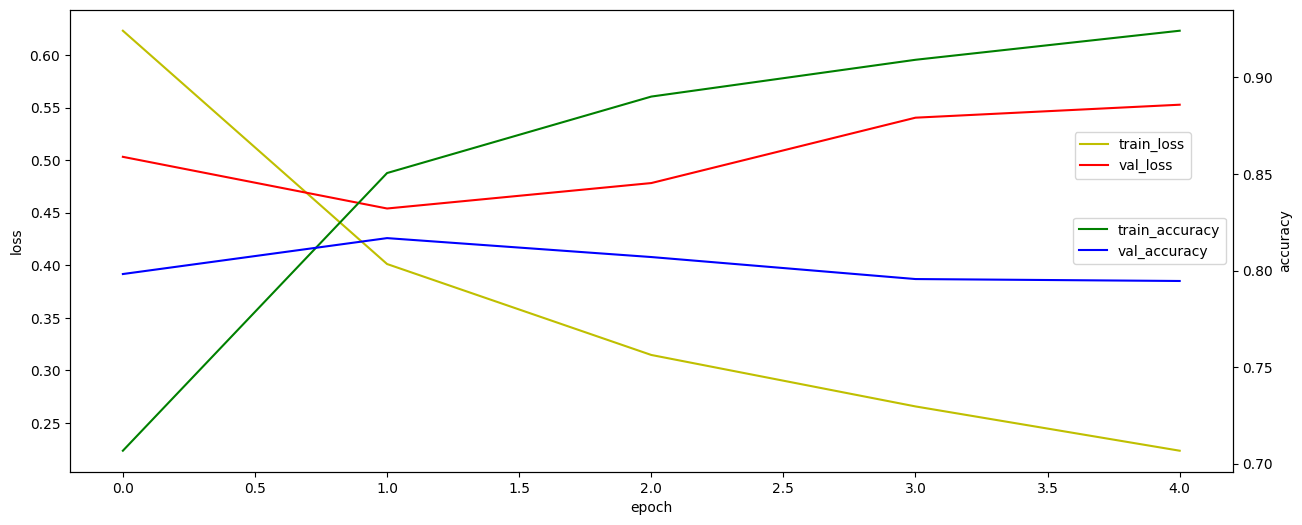

In [16]:
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['acc'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_acc'],'b',label='val_accuracy')

#acc_ax.plot(hist.history['val_recall'],'k',label='val_recall')


acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [17]:
loss, acc = model.evaluate(X_test, y_test, 
                           batch_size=MY_BATCH#batch_size 기본값이 32
                          )
print('test데이터의 정확도 :', acc)

125/125 [==============================] - 11s 91ms/step - loss: 0.4941 - acc: 0.7960
test데이터의 정확도 : 0.795960009098053


In [19]:
# 혼돈행렬, recall_score, precision_score, f1_score 계산을 위한 예측값
pred = model.predict(X_test, batch_size=MY_BATCH)
pred
y_hat = pred.argmax(axis=-1)
y_hat # 2차원

125/125 [==============================] - 7s 59ms/step


array([0, 1, 1, ..., 0, 0, 1], dtype=int64)

In [20]:
confusion_matrix(y_test, y_hat)

array([[9998, 2502],
       [2599, 9901]], dtype=int64)

In [22]:
pd.crosstab(y_test, y_hat)

col_0,0,1
row_0,,
0,9998,2502
1,2599,9901


In [23]:
'''
accuracy(정확도) = (TN+TP) / 전체수(TN+FP_FN+TP)
precision(정밀도) = TP / 예측을1이라고 한 수(FP+TP)
		예측값 기준
recall(재현율=민감도) = TP / 실제가 1인 수(FN+TP)
		실제값 기준
f1 score = recall과 precision의 조화평균
		2 * (precision*recall) / (precision+recall)
'''
print('recall :', recall_score(y_test, y_hat))
print('precision :', precision_score(y_test, y_hat))
print('f1-score :', f1_score(y_test, y_hat))
print('acc :', acc)

recall : 0.79208
precision : 0.7982746109812142
f1-score : 0.7951652411356062
acc : 0.795960009098053


# 12. 모델사용하기

In [24]:
review = '''It's a really great movie. The actors’ performances are good, and the 
story is solid as well. The sound was a little disappointing, though. 
There was a drawback in that I wanted to go to the bathroom in the middle. 
Because the screening time was long. 
The reservation rate wasn’t as high as I thought, so I booked it easily. 
Highly recommended. You probably won’t regret seeing it, ㅋㅋ @@'''.lower()

import re
review = re.sub('[^a-zA-Z\s]', ' ', review).split()
#print(review)
review_num = [1] + [word_to_id.get(word, -1)+3 for word in review]
review_num = [num if (num>0) & (num<10000) else 2 for num in review_num]
print(review_num)

[1, 12, 590, 6, 66, 87, 20, 4, 156, 354, 26, 52, 5, 4, 65, 9, 1156, 17, 73, 4, 481, 16, 6, 117, 1332, 151, 50, 16, 6, 2, 11, 15, 13, 473, 8, 140, 8, 4, 3868, 11, 4, 655, 88, 4, 2824, 58, 16, 196, 4, 2, 967, 2, 830, 17, 312, 17, 13, 197, 38, 13, 2, 12, 714, 545, 1178, 25, 242, 1199, 830, 2598, 319, 12]


In [25]:
input_data = pad_sequences([review_num],
               maxlen=MY_LENGTH,
               truncating='post', # 80단어 이상일 경우 어디를 짜를지 여부
               padding='pre', # 80단어 미만일 경우 앞에 zero를 붙임
               )
input_data.shape

(1, 80)

In [26]:
model.predict(input_data).argmax(axis=-1)

1/1 [==============================] - 0s 345ms/step


array([1], dtype=int64)

In [27]:
review = '''They say the higher the expectations, the bigger the disappointment, 
and that completely sums up this movie. While the fresh premise and flashy visuals 
initially caught my eye, it stopped right there. By the middle, the plot completely 
lost its logic, making the characters' actions impossible to understand.
The lines were so cheesy and cliché that it felt like a waste of the actors' solid 
performances. Dragging scenes had me constantly checking my watch, and even the 
climax left me feeling flat. The story got so tangled that it was hard to guess 
what message the director was try'''.lower()
review = [1] + [word_to_id.get(r, -1)+3 for r in review]
print(review)
input_data = pad_sequences([review],
               maxlen=MY_LENGTH,
               truncating='post', # 80단어 이상일 경우 어디를 짜를지 여부
               padding='pre', # 80단어 미만일 경우 앞에 zero를 붙임
               )
model.predict(input_data).argmax(axis=-1)

[1, 830, 2023, 963, 5135, 2, 590, 6, 5135, 2, 830, 2023, 963, 2, 2023, 13, 1331, 2023, 963, 1479, 2, 830, 2023, 963, 2, 963, 1745, 1657, 963, 1148, 830, 6, 830, 13, 1604, 3363, 590, 2, 2, 830, 2023, 963, 2, 503, 13, 1331, 1331, 963, 1479, 2, 830, 2023, 963, 2, 1095, 13, 590, 6, 1657, 1657, 1604, 13, 3363, 830, 1983, 963, 3363, 830, 2, 2, 2, 6, 3363, 1095, 2, 830, 2023, 6, 830, 2, 1148, 1604, 1983, 1657, 2014, 963, 830, 963, 2014, 5135, 2, 590, 1206, 1983, 590, 2, 1206, 1657, 2, 830, 2023, 13, 590, 2, 1983, 1604, 1964, 13, 963, 2, 2, 1992, 2023, 13, 2014, 963, 2, 830, 2023, 963, 2, 1209, 1479, 963, 590, 2023, 2, 1657, 1479, 963, 1983, 13, 590, 963, 2, 6, 3363, 1095, 2, 1209, 2014, 6, 590, 2023, 5135, 2, 1964, 13, 590, 1206, 6, 2014, 590, 2, 2, 13, 3363, 13, 830, 13, 6, 2014, 2014, 5135, 2, 1148, 6, 1206, 1331, 2023, 830, 2, 1983, 5135, 2, 963, 5135, 963, 2, 2, 13, 830, 2, 590, 830, 1604, 1657, 1657, 963, 1095, 2, 1479, 13, 1331, 2023, 830, 2, 830, 2023, 963, 1479, 963, 2, 2, 503, 5135, 

array([0], dtype=int64)